In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Change le répertoire de travail vers ton dossier
%cd "/content/drive/MyDrive/Projet Big Data"

/content/drive/MyDrive/Projet Big Data


In [5]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np
import time
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, accuracy_score, precision_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from category_encoders import TargetEncoder
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, roc_auc_score, recall_score, precision_score
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_recall_curve, recall_score, precision_score
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier

In [4]:
# Configuration de base
SEED = 1
Churn_Modelling = pd.read_csv('./data/Churn_Modelling.csv')

In [6]:

# 1. Séparation X et Y
X_raw = Churn_Modelling.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
Y = Churn_Modelling['Exited']

In [8]:
# 2. Pipeline de transformation avec TARGET ENCODING
categorical_features = ['Geography', 'Gender']
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Création du preprocessor avec Target Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', TargetEncoder(smoothing=1.0, min_samples_leaf=1), categorical_features)
    ])


In [9]:
# X prêt pour la Cross-Validation
X_transformed = preprocessor.fit_transform(X_raw, Y)  # Target Encoding nécessite Y

# Récupération des noms des variables pour la suite
all_features_names = numeric_features + categorical_features

print(f"Forme de X_transformed: {X_transformed.shape}")
print(f"Nombre de features: {len(all_features_names)}")
print(f"Features: {all_features_names}")

Forme de X_transformed: (10000, 10)
Nombre de features: 10
Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography', 'Gender']


In [11]:
# Fonction de score personnalisée (F2-Score)
def custom_metric(y_true, y_pred):
    # beta=2 permet de favoriser le rappel (détection des départs)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

custom_scorer = make_scorer(custom_metric)

# Dictionnaire des modèles à tester
clfs = {
    'LogisticReg': LogisticRegression(max_iter=1000, random_state=SEED),
    'CART': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(50, 25), random_state=SEED, max_iter=400),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Bagging': BaggingClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=SEED, algorithm='SAMME'),
    'RF': RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced'),
    'GradBoost': GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED)
}

In [14]:
def run_classifiers_cv_auto_select(X, Y, classifiers, metric_priority='F2-Score'):

    kf = KFold(n_splits=10, shuffle=True, random_state=SEED)
    results = []

    print(f"{'Algorithm':<15} | {'Accuracy':<10} | {'AUC':<10} | {'F2-Score':<10} | {'Time':<7}")
    print("-" * 70)

    for name, model in classifiers.items():
        start_time = time.time()

        # Calcul des métriques par CV
        cv_acc = cross_val_score(model, X, Y, cv=kf, scoring='accuracy')
        cv_auc = cross_val_score(model, X, Y, cv=kf, scoring='roc_auc')
        cv_custom = cross_val_score(model, X, Y, cv=kf, scoring=custom_scorer)

        exec_time = time.time() - start_time

        # Stockage des résultats
        results.append({
            'Model': name,
            'Accuracy': np.mean(cv_acc),
            'AUC': np.mean(cv_auc),
            'F2-Score': np.mean(cv_custom),
            'Time': exec_time,
            'Model_Object': model
        })

        print(f"{name:<15} | {np.mean(cv_acc):.3f}      | {np.mean(cv_auc):.3f}   | {np.mean(cv_custom):.3f}     | {exec_time:.2f}s")

    print("\n" + "="*70)

    # SÉLECTION AUTOMATIQUE DU MEILLEUR MODÈLE
    results_df = pd.DataFrame(results)
    best_idx = results_df[metric_priority].idxmax()
    best_model_info = results[best_idx]

    print(f"\n MEILLEUR MODÈLE SÉLECTIONNÉ (basé sur {metric_priority}):")
    print(f"   Modèle: {best_model_info['Model']}")
    print(f"   Accuracy: {best_model_info['Accuracy']:.4f}")
    print(f"   AUC: {best_model_info['AUC']:.4f}")
    print(f"   F2-Score: {best_model_info['F2-Score']:.4f}")
    print(f"   Temps d'exécution: {best_model_info['Time']:.2f}s")
    print("="*70)

    return best_model_info, results

In [15]:
best_model_info, all_results = run_classifiers_cv_auto_select(
    X_transformed,
    Y,
    clfs,
    metric_priority='F2-Score'  # Changez selon votre priorité
)

# Affichage d'un tableau comparatif
results_df = pd.DataFrame(all_results)
results_df = results_df.drop('Model_Object', axis=1)
results_df = results_df.sort_values('F2-Score', ascending=False)
print("\n CLASSEMENT DES MODÈLES:")
print(results_df.to_string(index=False))

Algorithm       | Accuracy   | AUC        | F2-Score   | Time   
----------------------------------------------------------------------
LogisticReg     | 0.813      | 0.765   | 0.236     | 2.20s
CART            | 0.855      | 0.839   | 0.478     | 1.29s
MLP             | 0.850      | 0.842   | 0.507     | 412.96s
KNN             | 0.842      | 0.797   | 0.432     | 2.10s
Bagging         | 0.857      | 0.846   | 0.522     | 299.36s


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

AdaBoost        | 0.856      | 0.848   | 0.492     | 60.15s
RF              | 0.863      | 0.858   | 0.499     | 111.07s
GradBoost       | 0.865      | 0.867   | 0.524     | 115.64s
SVM             | 0.854      | 0.812   | 0.414     | 389.30s


 MEILLEUR MODÈLE SÉLECTIONNÉ (basé sur F2-Score):
   Modèle: GradBoost
   Accuracy: 0.8649
   AUC: 0.8667
   F2-Score: 0.5238
   Temps d'exécution: 115.64s

 CLASSEMENT DES MODÈLES:
      Model  Accuracy      AUC  F2-Score       Time
  GradBoost    0.8649 0.866735  0.523778 115.642585
    Bagging    0.8569 0.846042  0.522102 299.357210
        MLP    0.8500 0.841781  0.507375 412.964642
         RF    0.8632 0.858198  0.498592 111.070884
   AdaBoost    0.8564 0.848025  0.491694  60.152947
       CART    0.8549 0.839249  0.477671   1.292744
        KNN    0.8417 0.796873  0.431503   2.098214
        SVM    0.8541 0.812248  0.414012 389.303042
LogisticReg    0.8132 0.765095  0.236060   2.203285


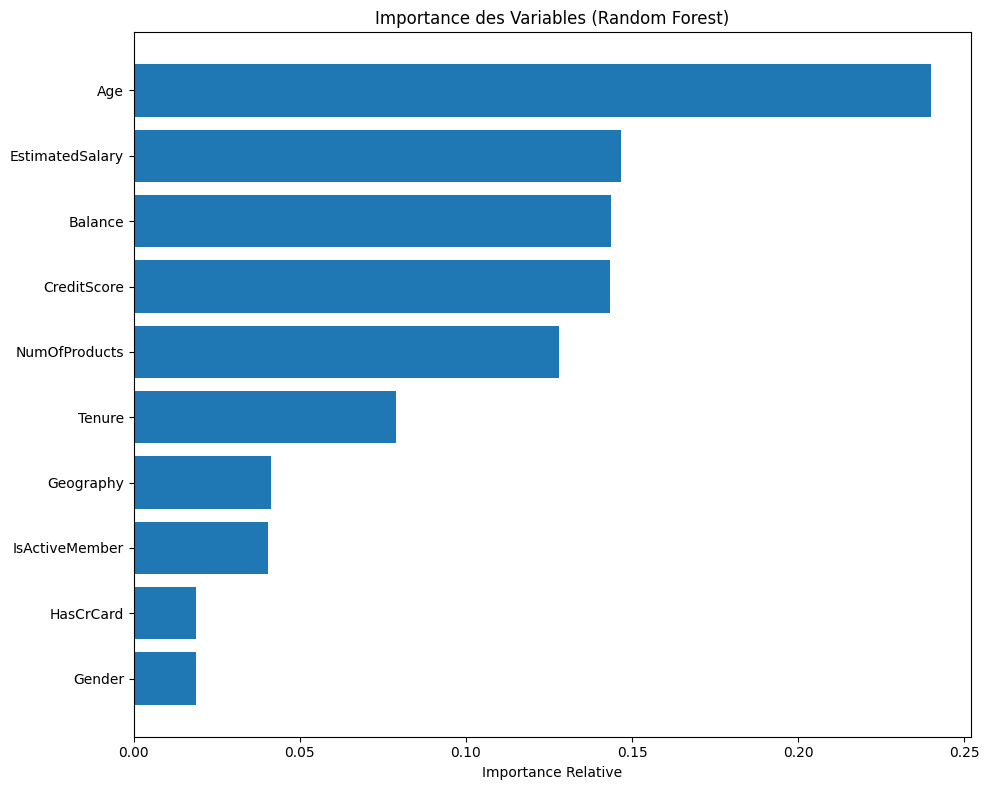

In [16]:
def importances_variables(X, Y, feature_names):
    # Entraînement du Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
    rf.fit(X, Y)

    # Extraction des importances
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Affichage
    plt.figure(figsize=(10, 8))
    plt.title("Importance des Variables (Random Forest)")
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Importance Relative")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return rf, indices

# Calcul de l'importance sur les données transformées
RF_model, ordre_features = importances_variables(X_transformed, Y, all_features_names)

Calcul de l'évolution du score...


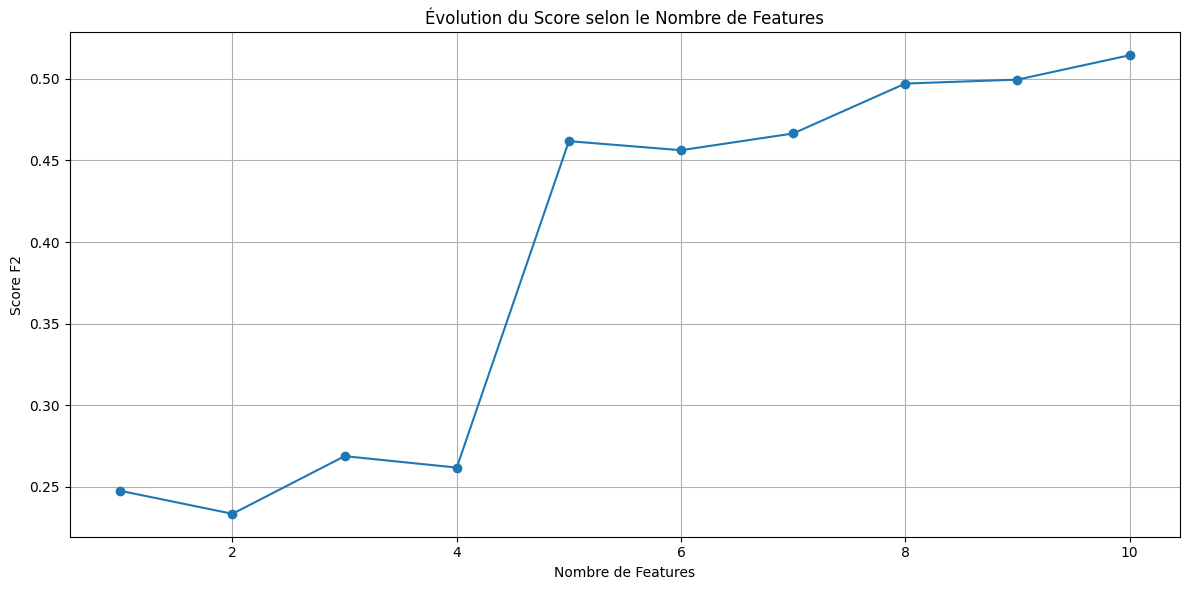


 Nombre optimal de features: 10
   Score maximal: 0.5144


In [17]:
def evolution_features(X, Y, clf, sorted_idx, score_func):
    # On split pour avoir un jeu de test fixe pour la courbe d'évolution
    X1, X2, Y1, Y2 = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=SEED)

    scores = np.zeros(X.shape[1])

    print("Calcul de l'évolution du score...")
    for f in np.arange(0, X.shape[1]):
        # Sélection progressive des variables selon l'ordre d'importance
        X1_f = X1[:, sorted_idx[:f+1]]
        X2_f = X2[:, sorted_idx[:f+1]]

        clf.fit(X1_f, Y1)
        y_pred = clf.predict(X2_f)
        scores[f] = score_func(Y2, y_pred)

    # Graphique
    plt.figure(figsize=(12, 6))
    plt.plot(np.arange(1, X.shape[1] + 1), scores, marker='o')
    plt.xlabel("Nombre de Features")
    plt.ylabel("Score F2")
    plt.title("Évolution du Score selon le Nombre de Features")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_nb = np.argmax(scores) + 1
    print(f"\n Nombre optimal de features: {best_nb}")
    print(f"   Score maximal: {scores[best_nb-1]:.4f}")

    return sorted_idx[:best_nb]

# Utilisation avec le meilleur modèle sélectionné automatiquement
selected_features = evolution_features(
    X_transformed,
    Y,
    best_model_info['Model_Object'],
    ordre_features,
    custom_metric
)

In [18]:
# Entraînement final avec features sélectionnées
X_selected = X_transformed[:, selected_features]
X_train, X_test, Y_train, Y_test = train_test_split(
    X_selected, Y, test_size=0.2, stratify=Y, random_state=SEED
)

# Entraînement du meilleur modèle
print(f"\n Entraînement du modèle final: {best_model_info['Model']}")
best_final_model = best_model_info['Model_Object']
best_final_model.fit(X_train, Y_train)

# Évaluation
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_final_model.predict(X_test)
y_proba = best_final_model.predict_proba(X_test)[:, 1]

print("\n PERFORMANCE SUR LE TEST SET:")
print(f"   Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"   AUC: {roc_auc_score(Y_test, y_proba):.4f}")
print(f"   F2-Score: {custom_metric(Y_test, y_pred):.4f}")
print("\n" + classification_report(Y_test, y_pred))


 Entraînement du modèle final: GradBoost

 PERFORMANCE SUR LE TEST SET:
   Accuracy: 0.8655
   AUC: 0.8571
   F2-Score: 0.5144

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [19]:
# Optimisation du seuil de décision
from sklearn.metrics import precision_recall_curve

# Calcul de la courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_proba)

# Calcul du F2-Score pour chaque seuil
f2_scores = []
for p, r in zip(precision, recall):
    if p + r > 0:
        f2 = (1 + 2**2) * (p * r) / ((2**2 * p) + r)
        f2_scores.append(f2)
    else:
        f2_scores.append(0)

# Seuil optimal
optimal_idx = np.argmax(f2_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"\n SEUIL OPTIMAL: {optimal_threshold:.4f}")
print(f"   F2-Score maximal: {max(f2_scores):.4f}")

# Prédictions avec seuil optimisé
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print("\n PERFORMANCE AVEC SEUIL OPTIMISÉ:")
print(classification_report(Y_test, y_pred_optimal))


 SEUIL OPTIMAL: 0.1499
   F2-Score maximal: 0.6924

 PERFORMANCE AVEC SEUIL OPTIMISÉ:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82      1593
           1       0.44      0.81      0.57       407

    accuracy                           0.75      2000
   macro avg       0.69      0.77      0.70      2000
weighted avg       0.84      0.75      0.77      2000



<Figure size 800x600 with 0 Axes>

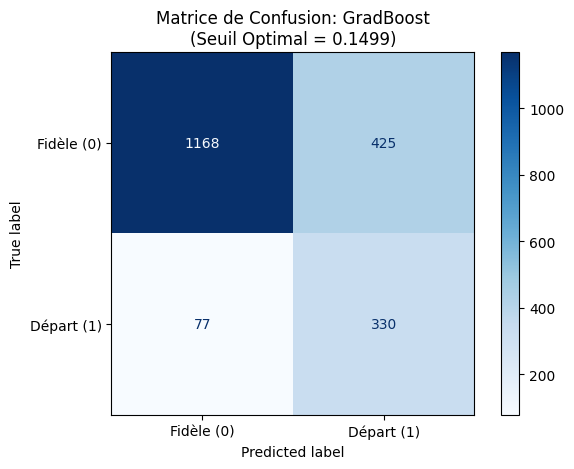

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice de confusion avec seuil optimisé
cm = confusion_matrix(Y_test, y_pred_optimal)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fidèle (0)', 'Départ (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Matrice de Confusion: {best_model_info['Model']}\n(Seuil Optimal = {optimal_threshold:.4f})")
plt.tight_layout()
plt.show()

 TOP 3 MEILLEURS MODÈLES
    Model  Accuracy      AUC  F2-Score       Time
GradBoost    0.8649 0.866735  0.523778 115.642585
  Bagging    0.8569 0.846042  0.522102 299.357210
      MLP    0.8500 0.841781  0.507375 412.964642

 Modèle #1: GradBoost

 Seuil optimal: 0.1499
 Métriques de performance:
              precision    recall  f1-score   support

  Fidèle (0)       0.94      0.73      0.82      1593
  Départ (1)       0.44      0.81      0.57       407

    accuracy                           0.75      2000
   macro avg       0.69      0.77      0.70      2000
weighted avg       0.84      0.75      0.77      2000


 Modèle #2: Bagging

 Seuil optimal: 0.0800
 Métriques de performance:
              precision    recall  f1-score   support

  Fidèle (0)       0.96      0.53      0.68      1593
  Départ (1)       0.33      0.91      0.48       407

    accuracy                           0.61      2000
   macro avg       0.64      0.72      0.58      2000
weighted avg       0.83      0

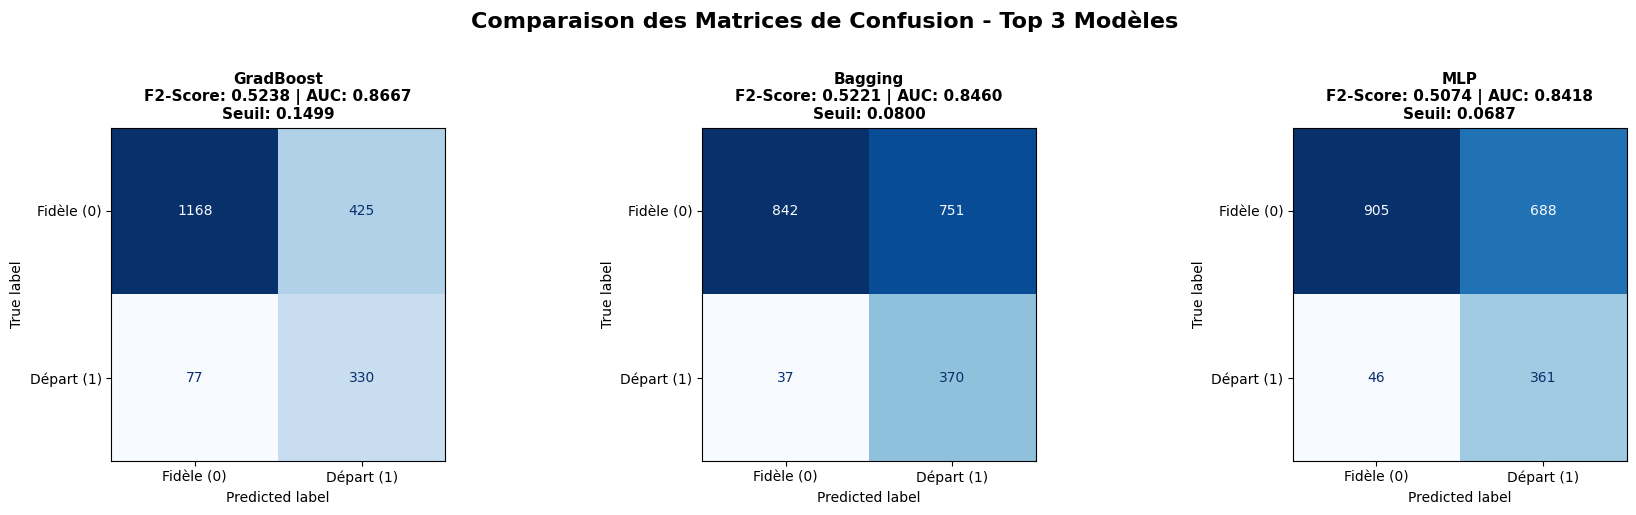


 TABLEAU RÉCAPITULATIF DES PERFORMANCES
Rang    Modèle  Accuracy      AUC  F2-Score   Recall  Precision    Seuil
  #1 GradBoost     0.749 0.857078  0.692405 0.810811   0.437086 0.149888
  #2   Bagging     0.606 0.833003  0.672972 0.909091   0.330062 0.080000
  #3       MLP     0.633 0.839149  0.674262 0.886978   0.344137 0.068700


In [21]:
# Sélection des 3 meilleurs modèles basés sur F2-Score
results_df_comp = pd.DataFrame(all_results)
top_3_models = results_df_comp.nlargest(3, 'F2-Score')

print("="*70)
print(" TOP 3 MEILLEURS MODÈLES")
print("="*70)
print(top_3_models[['Model', 'Accuracy', 'AUC', 'F2-Score', 'Time']].to_string(index=False))
print("="*70)

# Préparation de la figure pour 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des Matrices de Confusion - Top 3 Modèles',
             fontsize=16, fontweight='bold', y=1.02)

# Pour stocker les résultats détaillés
top_3_detailed_results = []

# Pour chaque modèle du top 3
for idx, (ax, model_idx) in enumerate(zip(axes, top_3_models.index)):
    model_info = all_results[model_idx]
    model = model_info['Model_Object']
    model_name = model_info['Model']

    print(f"\n{'='*70}")
    print(f" Modèle #{idx+1}: {model_name}")
    print(f"{'='*70}")

    # Entraînement du modèle sur les features sélectionnées
    X_selected_temp = X_transformed[:, selected_features]
    X_train_temp, X_test_temp, Y_train_temp, Y_test_temp = train_test_split(
        X_selected_temp, Y, test_size=0.2, stratify=Y, random_state=SEED
    )

    # Entraînement
    model.fit(X_train_temp, Y_train_temp)

    # Prédictions
    y_proba_temp = model.predict_proba(X_test_temp)[:, 1]

    # Calcul du seuil optimal pour ce modèle
    precision_temp, recall_temp, thresholds_temp = precision_recall_curve(Y_test_temp, y_proba_temp)

    f2_scores_temp = []
    for p, r in zip(precision_temp, recall_temp):
        if p + r > 0:
            f2 = (1 + 2**2) * (p * r) / ((2**2 * p) + r)
            f2_scores_temp.append(f2)
        else:
            f2_scores_temp.append(0)

    optimal_idx_temp = np.argmax(f2_scores_temp)
    optimal_threshold_temp = thresholds_temp[optimal_idx_temp] if optimal_idx_temp < len(thresholds_temp) else 0.5

    # Prédictions avec seuil optimisé
    y_pred_optimal_temp = (y_proba_temp >= optimal_threshold_temp).astype(int)

    # Matrice de confusion
    cm = confusion_matrix(Y_test_temp, y_pred_optimal_temp)

    # Affichage de la matrice
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fidèle (0)', 'Départ (1)'])
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)

    # Titre avec métriques
    ax.set_title(f"{model_name}\nF2-Score: {model_info['F2-Score']:.4f} | "
                f"AUC: {model_info['AUC']:.4f}\nSeuil: {optimal_threshold_temp:.4f}",
                fontsize=11, fontweight='bold')

    # Calcul des métriques détaillées
    detailed_metrics = {
        'Rang': f"#{idx+1}",
        'Modèle': model_name,
        'Accuracy': accuracy_score(Y_test_temp, y_pred_optimal_temp),
        'AUC': roc_auc_score(Y_test_temp, y_proba_temp),
        'F2-Score': custom_metric(Y_test_temp, y_pred_optimal_temp),
        'Recall': recall_score(Y_test_temp, y_pred_optimal_temp),
        'Precision': precision_score(Y_test_temp, y_pred_optimal_temp),
        'Seuil': optimal_threshold_temp
    }
    top_3_detailed_results.append(detailed_metrics)

    # Rapport détaillé
    print(f"\n Seuil optimal: {optimal_threshold_temp:.4f}")
    print(f" Métriques de performance:")
    print(classification_report(Y_test_temp, y_pred_optimal_temp,
                               target_names=['Fidèle (0)', 'Départ (1)']))

plt.tight_layout()
plt.show()

# Tableau récapitulatif des performances
print("\n" + "="*70)
print(" TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("="*70)

summary_df = pd.DataFrame(top_3_detailed_results)
print(summary_df.to_string(index=False))
print("="*70)

In [25]:
print("="*70)
print(" STACKING DES 3 MEILLEURS MODÈLES")
print("="*70)

# Récupération des 3 meilleurs modèles
results_df_stacking = pd.DataFrame(all_results)
top_3_models = results_df_stacking.nlargest(3, 'F2-Score')

print("\n Modèles utilisés pour le stacking:")
for idx, model_idx in enumerate(top_3_models.index):
    model_info = all_results[model_idx]
    print(f"   #{idx+1}: {model_info['Model']} (F2-Score: {model_info['F2-Score']:.4f})")

# Création de la liste des estimateurs pour le stacking
estimators = []
for idx, model_idx in enumerate(top_3_models.index):
    model_info = all_results[model_idx]
    model_name = model_info['Model']
    model_obj = model_info['Model_Object']
    estimators.append((f'model_{idx+1}_{model_name}', model_obj))

# Création du modèle de stacking avec Régression Logistique comme meta-modèle
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=5,  # Cross-validation pour éviter l'overfitting
    stack_method='predict_proba',  # Utilise les probabilités des modèles de base
    n_jobs=-1
)

 STACKING DES 3 MEILLEURS MODÈLES

 Modèles utilisés pour le stacking:
   #1: GradBoost (F2-Score: 0.5238)
   #2: Bagging (F2-Score: 0.5221)
   #3: MLP (F2-Score: 0.5074)


In [26]:
print("\n Configuration du Stacking:")
print(f"   - Nombre de modèles de base: {len(estimators)}")
print(f"   - Meta-modèle: Logistic Regression")
print(f"   - Méthode de stacking: predict_proba")
print(f"   - Cross-validation: 5 folds")

# Entraînement sur les features sélectionnées
X_selected = X_transformed[:, selected_features]
X_train_stack, X_test_stack, Y_train_stack, Y_test_stack = train_test_split(
    X_selected, Y, test_size=0.2, stratify=Y, random_state=SEED
)

print("\n Entraînement du modèle de stacking en cours...")
import time
start_time = time.time()
stacking_model.fit(X_train_stack, Y_train_stack)
training_time = time.time() - start_time
print(f" Entraînement terminé en {training_time:.2f}s")

# Prédictions
y_pred_stack = stacking_model.predict(X_test_stack)
y_proba_stack = stacking_model.predict_proba(X_test_stack)[:, 1]

# Calcul des métriques de base
accuracy_stack = accuracy_score(Y_test_stack, y_pred_stack)
auc_stack = roc_auc_score(Y_test_stack, y_proba_stack)
f2_score_stack = custom_metric(Y_test_stack, y_pred_stack)

print("\n" + "="*70)
print(" PERFORMANCE DU MODÈLE DE STACKING (seuil par défaut 0.5)")
print("="*70)
print(f"   Accuracy: {accuracy_stack:.4f}")
print(f"   AUC: {auc_stack:.4f}")
print(f"   F2-Score: {f2_score_stack:.4f}")
print("\n" + classification_report(Y_test_stack, y_pred_stack, target_names=['Fidèle (0)', 'Départ (1)']))


 Configuration du Stacking:
   - Nombre de modèles de base: 3
   - Meta-modèle: Logistic Regression
   - Méthode de stacking: predict_proba
   - Cross-validation: 5 folds

 Entraînement du modèle de stacking en cours...
 Entraînement terminé en 140.38s

 PERFORMANCE DU MODÈLE DE STACKING (seuil par défaut 0.5)
   Accuracy: 0.8655
   AUC: 0.8582
   F2-Score: 0.5144

              precision    recall  f1-score   support

  Fidèle (0)       0.88      0.97      0.92      1593
  Départ (1)       0.78      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [27]:
# Optimisation du seuil pour le stacking
precision_stack, recall_stack, thresholds_stack = precision_recall_curve(Y_test_stack, y_proba_stack)

f2_scores_stack = []
for p, r in zip(precision_stack, recall_stack):
    if p + r > 0:
        f2 = (1 + 2**2) * (p * r) / ((2**2 * p) + r)
        f2_scores_stack.append(f2)
    else:
        f2_scores_stack.append(0)

optimal_idx_stack = np.argmax(f2_scores_stack)
optimal_threshold_stack = thresholds_stack[optimal_idx_stack] if optimal_idx_stack < len(thresholds_stack) else 0.5

print("\n" + "="*70)
print(f" SEUIL OPTIMAL POUR LE STACKING: {optimal_threshold_stack:.4f}")
print("="*70)

# Prédictions avec seuil optimisé
y_pred_stack_optimal = (y_proba_stack >= optimal_threshold_stack).astype(int)

# Métriques avec seuil optimisé
accuracy_stack_opt = accuracy_score(Y_test_stack, y_pred_stack_optimal)
f2_score_stack_opt = custom_metric(Y_test_stack, y_pred_stack_optimal)
recall_stack_opt = recall_score(Y_test_stack, y_pred_stack_optimal)
precision_stack_opt = precision_score(Y_test_stack, y_pred_stack_optimal)

print("\n PERFORMANCE AVEC SEUIL OPTIMISÉ:")
print(f"   Accuracy: {accuracy_stack_opt:.4f}")
print(f"   AUC: {auc_stack:.4f}")
print(f"   F2-Score: {f2_score_stack_opt:.4f}")
print(f"   Recall: {recall_stack_opt:.4f}")
print(f"   Precision: {precision_stack_opt:.4f}")
print("\n" + classification_report(Y_test_stack, y_pred_stack_optimal, target_names=['Fidèle (0)', 'Départ (1)']))


 SEUIL OPTIMAL POUR LE STACKING: 0.0938

 PERFORMANCE AVEC SEUIL OPTIMISÉ:
   Accuracy: 0.6780
   AUC: 0.8582
   F2-Score: 0.6893
   Recall: 0.8722
   Precision: 0.3749

              precision    recall  f1-score   support

  Fidèle (0)       0.95      0.63      0.76      1593
  Départ (1)       0.37      0.87      0.52       407

    accuracy                           0.68      2000
   macro avg       0.66      0.75      0.64      2000
weighted avg       0.83      0.68      0.71      2000



<Figure size 800x600 with 0 Axes>

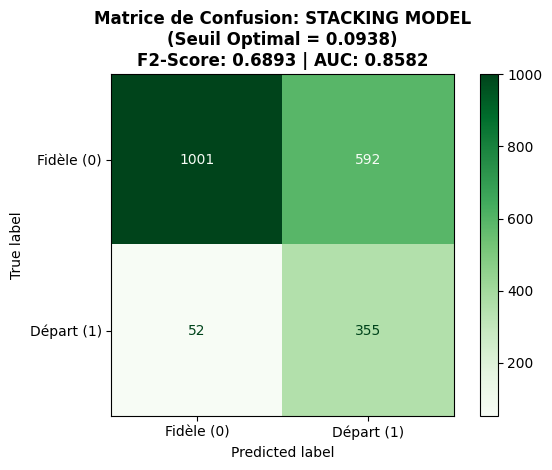


 COMPARAISON: STACKING vs MODÈLES INDIVIDUELS
           Modèle Accuracy    AUC F2-Score Recall Precision
 STACKING (Top 3)   0.6780 0.8582   0.6893 0.8722    0.3749
        GradBoost   0.8649 0.8667   0.5238      -         -
          Bagging   0.8569 0.8460   0.5221      -         -
              MLP   0.8500 0.8418   0.5074      -         -

 ANALYSE:
    Le stacking améliore le F2-Score de 31.61%
   Meilleur modèle individuel: GradBoost (F2: 0.5238)
   Stacking: F2-Score = 0.6893


In [28]:
# Matrice de confusion du modèle de stacking
cm_stack = confusion_matrix(Y_test_stack, y_pred_stack_optimal)

plt.figure(figsize=(8, 6))
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=['Fidèle (0)', 'Départ (1)'])
disp_stack.plot(cmap='Greens', values_format='d')
plt.title(f"Matrice de Confusion: STACKING MODEL\n(Seuil Optimal = {optimal_threshold_stack:.4f})\nF2-Score: {f2_score_stack_opt:.4f} | AUC: {auc_stack:.4f}",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparaison avec les modèles individuels
print("\n" + "="*70)
print(" COMPARAISON: STACKING vs MODÈLES INDIVIDUELS")
print("="*70)
comparison_data = []

# Ajout des résultats du stacking
comparison_data.append({
    'Modèle': ' STACKING (Top 3)',
    'Accuracy': f"{accuracy_stack_opt:.4f}",
    'AUC': f"{auc_stack:.4f}",
    'F2-Score': f"{f2_score_stack_opt:.4f}",
    'Recall': f"{recall_stack_opt:.4f}",
    'Precision': f"{precision_stack_opt:.4f}"
})

# Ajout des résultats des modèles individuels (Top 3)
for idx, model_idx in enumerate(top_3_models.index):
    model_info = all_results[model_idx]
    comparison_data.append({
        'Modèle': f"   {model_info['Model']}",
        'Accuracy': f"{model_info['Accuracy']:.4f}",
        'AUC': f"{model_info['AUC']:.4f}",
        'F2-Score': f"{model_info['F2-Score']:.4f}",
        'Recall': '-',
        'Precision': '-'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("="*70)

# Gain du stacking
best_individual_f2 = top_3_models.iloc[0]['F2-Score']
gain_percentage = ((f2_score_stack_opt - best_individual_f2) / best_individual_f2) * 100

print(f"\n ANALYSE:")
if gain_percentage > 0:
    print(f"    Le stacking améliore le F2-Score de {gain_percentage:.2f}%")
elif gain_percentage < 0:
    print(f"     Le stacking réduit le F2-Score de {abs(gain_percentage):.2f}%")
else:
    print(f"     Le stacking obtient un F2-Score similaire")

print(f"   Meilleur modèle individuel: {top_3_models.iloc[0]['Model']} (F2: {best_individual_f2:.4f})")
print(f"   Stacking: F2-Score = {f2_score_stack_opt:.4f}")

In [29]:
import os, pickle

os.makedirs('artifacts', exist_ok=True)

# 1. Sauvegarde du modèle STACKING (et non best_final_model)
with open('artifacts/model.pickle', 'wb') as f:
    pickle.dump(stacking_model, f)

# 2. Sauvegarde du preprocessor (Target Encoding + Scaling)
with open('artifacts/scaler.pickle', 'wb') as f:
    pickle.dump(preprocessor, f)

# 3. Sauvegarde de la liste des noms de colonnes attendues en entrée
input_columns = X_raw.columns.tolist()
with open('artifacts/input_columns.pickle', 'wb') as f:
    pickle.dump(input_columns, f)

# 4. Sauvegarde de la sélection de variables
with open('artifacts/pca.pickle', 'wb') as f:
    pickle.dump(selected_features, f)

# 5. Sauvegarde du seuil optimal DU STACKING
with open('artifacts/optimal_threshold.pickle', 'wb') as f:
    pickle.dump(optimal_threshold_stack, f)   # ← optimal_threshold_stack et non optimal_threshold

# 6. Sauvegarde des informations du modèle STACKING
model_info = {
    'name': 'Stacking (GradBoost + Bagging + MLP)',
    'accuracy': accuracy_stack_opt,            # ← métriques du stacking
    'auc': auc_stack,
    'f2_score': f2_score_stack_opt,
    'optimal_threshold': optimal_threshold_stack
}
with open('artifacts/model_info.pickle', 'wb') as f:
    pickle.dump(model_info, f)

print("Tous les artefacts ont été sauvegardés avec succès!")
print(f"\n Contenu du dossier artifacts:")
print("   - model.pickle          → Stacking (GradBoost + Bagging + MLP)")
print("   - scaler.pickle         → Preprocessor avec Target Encoding")
print("   - input_columns.pickle  → Colonnes d'entrée")
print("   - pca.pickle            → Features sélectionnées")
print(f"  - optimal_threshold.pickle → Seuil = {optimal_threshold_stack:.4f}")
print("   - model_info.pickle     → Métriques du modèle final")

Tous les artefacts ont été sauvegardés avec succès!

 Contenu du dossier artifacts:
   - model.pickle          → Stacking (GradBoost + Bagging + MLP)
   - scaler.pickle         → Preprocessor avec Target Encoding
   - input_columns.pickle  → Colonnes d'entrée
   - pca.pickle            → Features sélectionnées
  - optimal_threshold.pickle → Seuil = 0.0938
   - model_info.pickle     → Métriques du modèle final
